# **Exploratory Data Analysis**

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
eda_df = pd.read_csv('dataset/cleaned/ecommerce_cleaned.csv')

In [3]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000123 entries, 0 to 1000122
Data columns (total 31 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_date              1000123 non-null  object 
 1   order_year              1000123 non-null  int64  
 2   order_month             1000123 non-null  int64  
 3   customer_name           1000123 non-null  object 
 4   gender                  1000123 non-null  object 
 5   age                     1000123 non-null  int64  
 6   customer_segment        1000123 non-null  object 
 7   country                 1000123 non-null  object 
 8   category                1000123 non-null  object 
 9   sub_category            1000123 non-null  object 
 10  unit_price_usd          1000123 non-null  float64
 11  quantity                1000123 non-null  int64  
 12  discount_percent        1000123 non-null  int64  
 13  revenue_usd             1000123 non-null  float64
 14  pr

In [4]:
# Missing values (%)
print(((eda_df.isnull().sum() / len(eda_df)) * 100).to_string())

order_date               0.00
order_year               0.00
order_month              0.00
customer_name            0.00
gender                   0.00
age                      0.00
customer_segment         0.00
country                  0.00
category                 0.00
sub_category             0.00
unit_price_usd           0.00
quantity                 0.00
discount_percent         0.00
revenue_usd              0.00
profit_usd               0.00
profit_margin_percent    0.00
payment_method           0.00
shipping_method          0.00
shipping_cost_usd        0.00
delivery_days            0.00
shipping_country         0.00
rating                   0.00
customer_loyalty_score   0.00
coupon_used              0.00
session_duration_min     0.00
pages_visited            0.00
abandoned_cart_before    0.00
fraud_risk_score         0.00
device_type              0.00
campaign_source          0.00
traffic_source           0.00


### **Identify outliers, distribution, and skewed data using Histogram**

In [6]:
eda_df.columns

Index(['order_date', 'order_year', 'order_month', 'customer_name', 'gender',
       'age', 'customer_segment', 'country', 'category', 'sub_category',
       'unit_price_usd', 'quantity', 'discount_percent', 'revenue_usd',
       'profit_usd', 'profit_margin_percent', 'payment_method',
       'shipping_method', 'shipping_cost_usd', 'delivery_days',
       'shipping_country', 'rating', 'customer_loyalty_score', 'coupon_used',
       'session_duration_min', 'pages_visited', 'abandoned_cart_before',
       'fraud_risk_score', 'device_type', 'campaign_source', 'traffic_source'],
      dtype='object')

In [7]:
eda_df.sample(5)

,order_date,order_year,order_month,customer_name,gender,age,customer_segment,country,category,sub_category,unit_price_usd,quantity,discount_percent,revenue_usd,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,delivery_days,shipping_country,rating,customer_loyalty_score,coupon_used,session_duration_min,pages_visited,abandoned_cart_before,fraud_risk_score,device_type,campaign_source,traffic_source
476646,2025-03-27 18:33:42.119731,2025,3,Robert Calderon,Male,39,Regular,Germany,Health,Fitness,189.87,1,5,180.38,66.54,36.89,PayPal,Express,18.42,1,Germany,2,49.30,No,56.10,12,No,49.60,Desktop,Instagram,Direct
160862,2024-05-10 09:54:13.338012,2024,5,Edwin Vasquez,Male,52,Regular,Italy,Electronics,Smartphones,43.10,3,20,103.44,20.76,20.07,Bank Transfer,Express,8.12,9,Italy,2,43.90,No,52.90,12,Yes,18.30,Desktop,Instagram,Referral
447016,2025-05-28 18:08:05.348133,2025,5,Sarah Morgan,Female,39,Regular,Belgium,Electronics,Audio,90.21,4,15,306.71,79.03,25.77,Credit Card,Next Day,10.18,8,Belgium,5,35.00,No,50.20,11,No,87.80,Tablet,Instagram,Direct
522066,2024-10-15 06:01:24.716768,2024,10,Caitlin Brown,Female,48,Premium,Germany,Electronics,Laptops,76.30,5,0,381.50,143.10,37.51,Apple Pay,Economy,7.26,6,Germany,3,81.20,Yes,16.20,19,No,53.10,Mobile,Instagram,Search
414885,2024-12-05 17:33:25.584479,2024,12,Marie Doyle,Female,38,VIP,Canada,Electronics,Accessories,160.14,2,0,320.28,120.50,37.62,Debit Card,Express,13.52,11,Canada,5,60.00,No,25.30,5,No,37.60,Desktop,Instagram,Social


### IQR to Detect Outlier for All Numeric Columns

In [8]:
# Detect outliers in numeric columns using the IQR rule.
numeric_cols = eda_df.select_dtypes(include='number')

for col in numeric_cols:
    Q1 = eda_df[col].quantile(0.25)
    Q3 = eda_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = eda_df[
        (eda_df[col] < lower) |
        (eda_df[col] > upper)
    ]

    count = len(outliers)
    percent = (count / len(eda_df)) * 100

    if round(percent, 2) > 0:
        print(f"{col}: {count:,} outliers")
        print(f"{col} in percent (%) : {percent:.2f}% outliers\n")

unit_price_usd: 47,098 outliers
unit_price_usd in percent (%) : 4.71% outliers

revenue_usd: 49,298 outliers
revenue_usd in percent (%) : 4.93% outliers

profit_usd: 56,873 outliers
profit_usd in percent (%) : 5.69% outliers

profit_margin_percent: 352 outliers
profit_margin_percent in percent (%) : 0.04% outliers



Based on the IQR method, four columns were identified as containing potential outliers: **``unit_price_usd``**, **``revenue_usd``**, **``profit_usd``**, and **``profit_margin_percent``**. Among these, **``unit_price_usd``** (4.71%), **``revenue_usd``** (4.93%), and **``profit_usd``** (5.69%) exhibit a relatively similar proportion of outliers (approximately 5%), whereas **``profit_margin_percent``** contains only 0.04% outliers. To determine whether these detected outliers represent legitimate business observations or anomalous values, visualizations such as box plots and histograms will be used for further investigation.

### Numerical and Categorical Variables

In [9]:
categorical_cols = [
    'gender',
    'customer_segment',
    'category',
    'payment_method',
    'shipping_method',
    'device_type',
    'campaign_source',
    'traffic_source',
    'coupon_used',
    'abandoned_cart_before'
]

discrete_cols = [
    'quantity',
    'rating',
    'delivery_days',
    'discount_percent',
    'pages_visited',
    'order_month'
]

continuous_cols = [
    'unit_price_usd',
    'revenue_usd',
    'profit_usd',
    'profit_margin_percent',
    'shipping_cost_usd',
    'session_duration_min',
    'fraud_risk_score',
    'customer_loyalty_score'
]

### Histogram

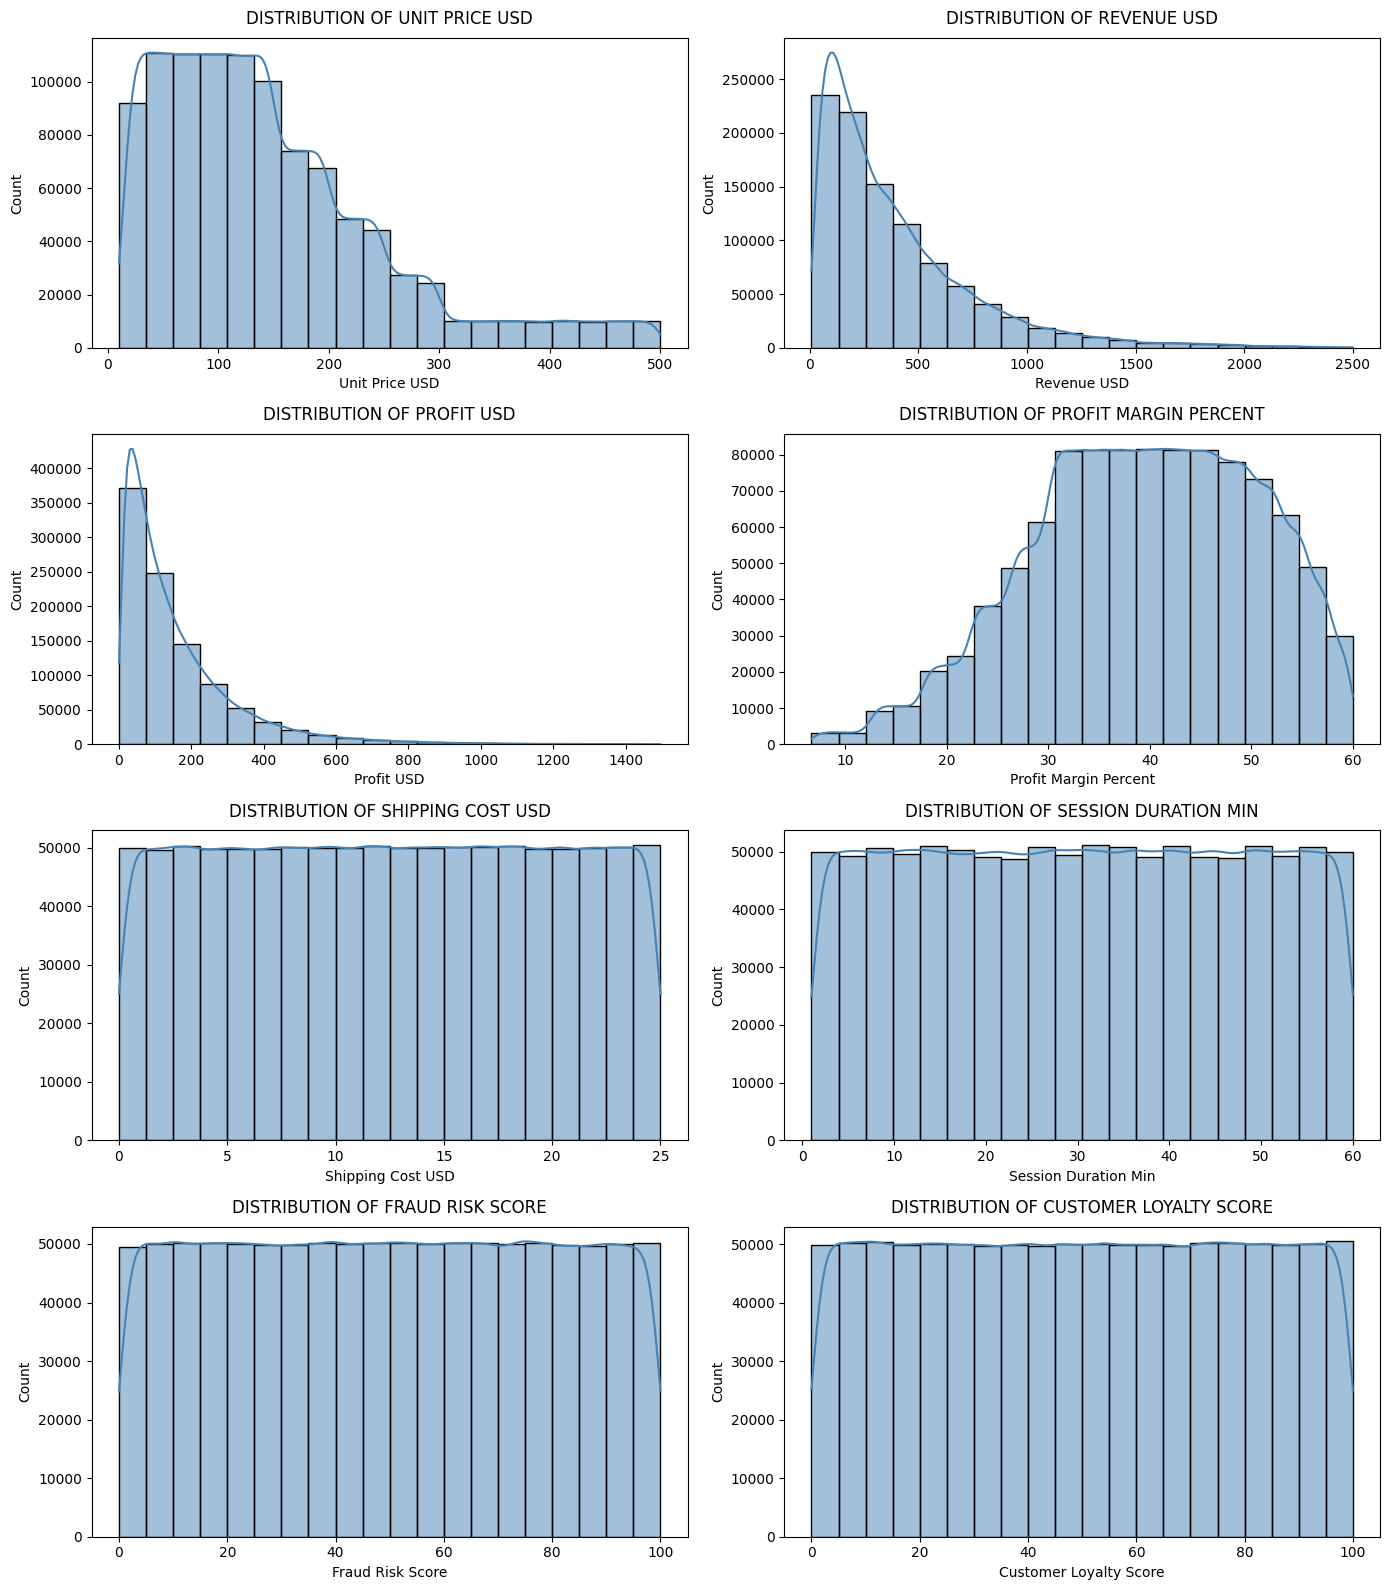

In [10]:
# Histogram Distribution of Continuous Variables

n_cols = 2
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  
for i, cons in enumerate(continuous_cols):
    ax = axes[i]
    
    sns.histplot(
        data=eda_df,
        x=cons,
        bins=20,
        ax=ax,
        color='steelblue',
        kde=True
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')

# Hide empty subplots (kung hindi exact multiple of 2)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Boxplot

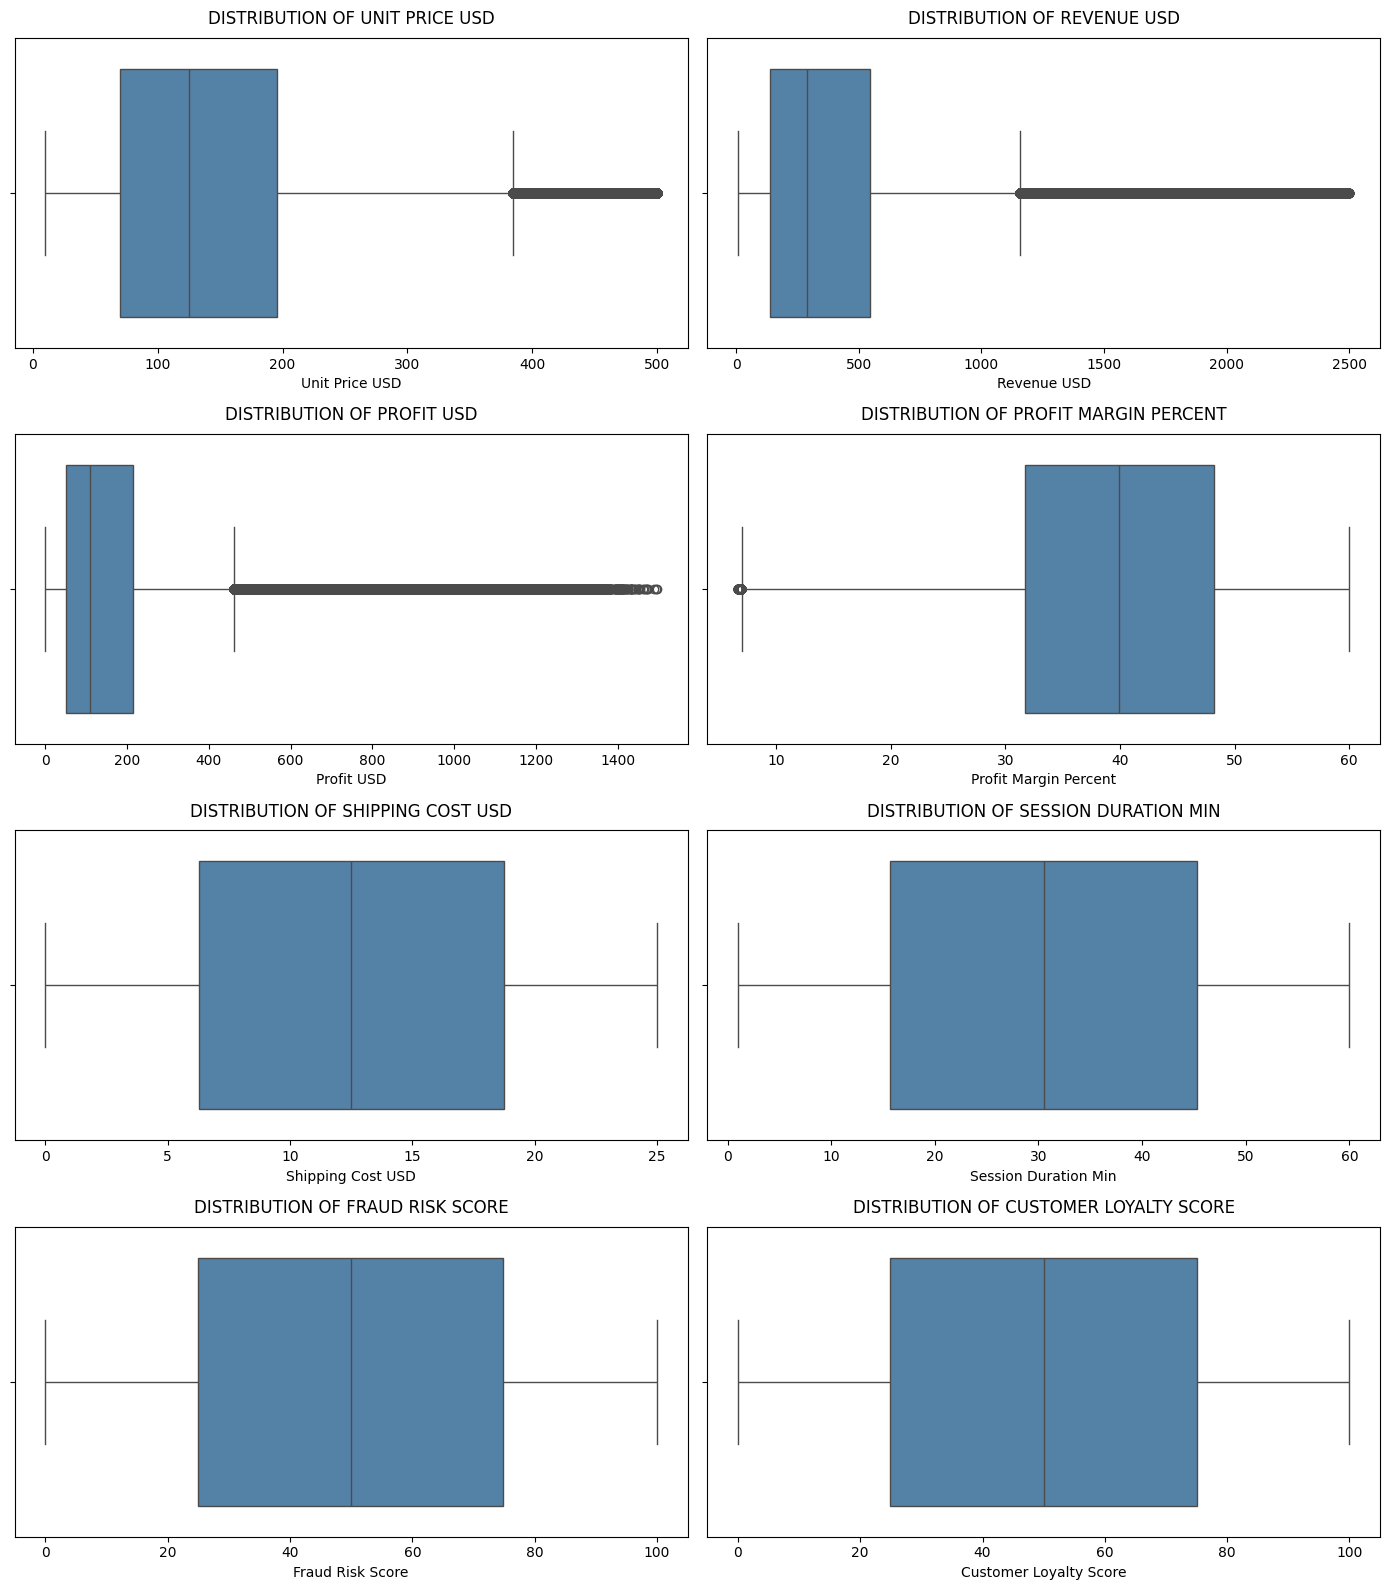

In [11]:
# Boxplot Distribution of Continuous Variables
n_cols = 2
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  
for i, cons in enumerate(continuous_cols):
    ax = axes[i]
    
    sns.boxplot(
        data=eda_df,
        x=cons,
        ax=ax,
        color='steelblue'
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)

# Hide empty subplots (kung hindi exact multiple of 2)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

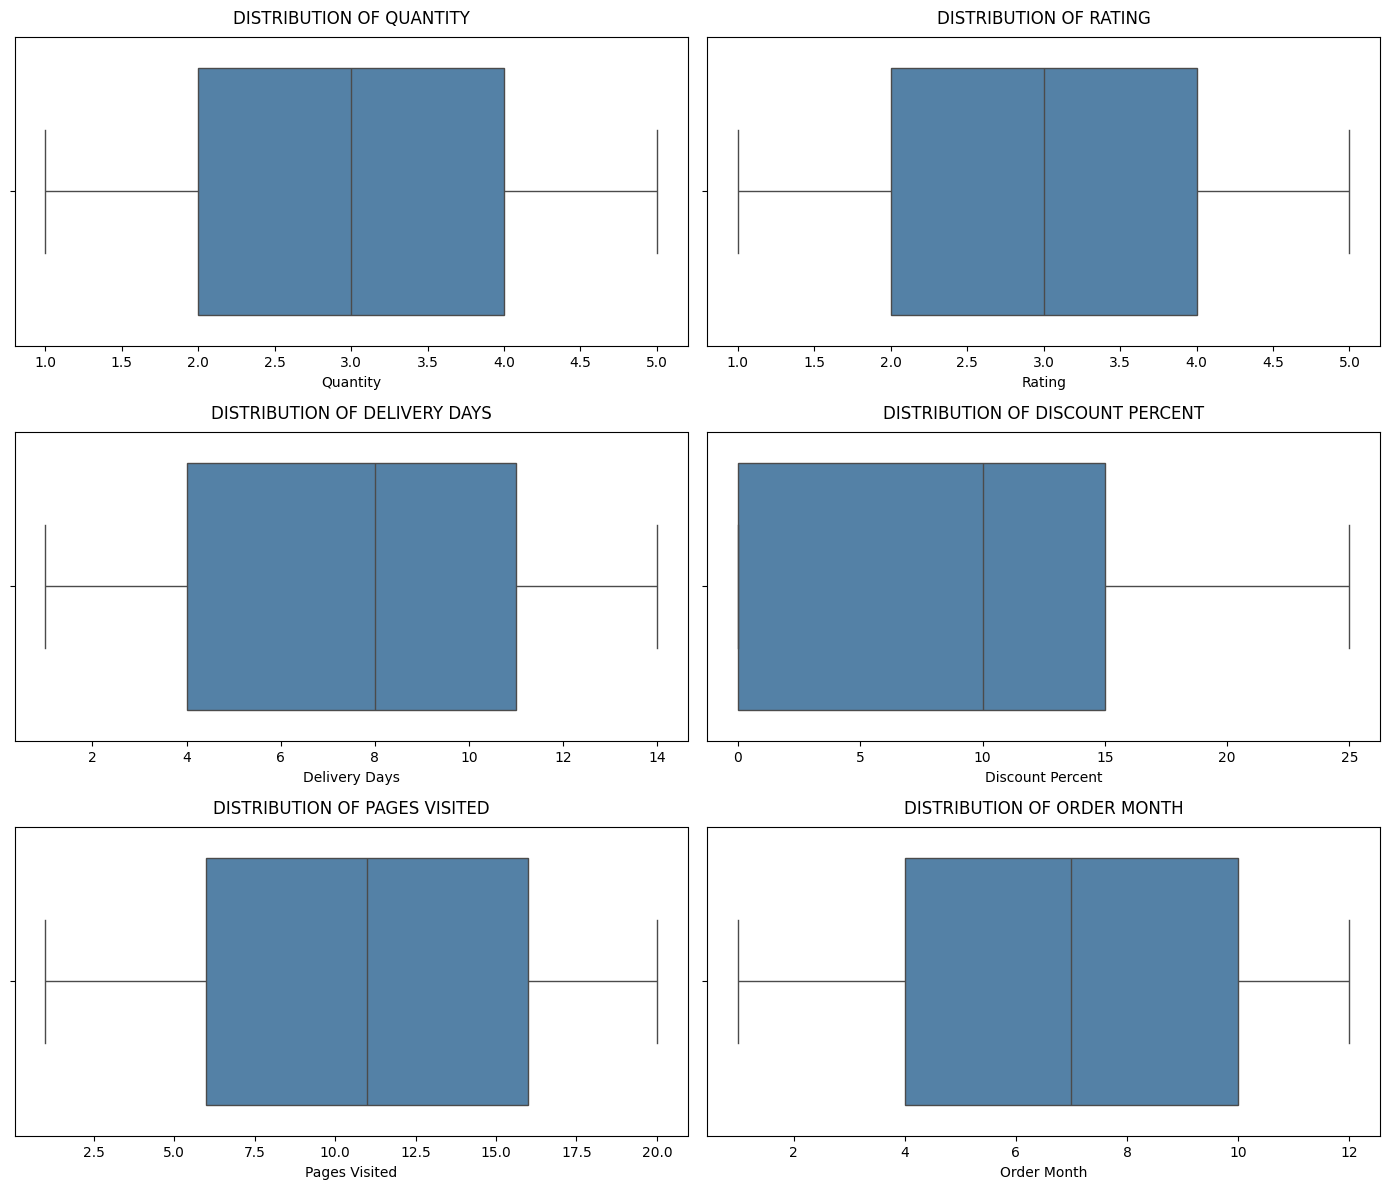

In [12]:
# Boxplot Distribution of Discrete Variables
n_cols = 2
n_rows = math.ceil(len(discrete_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  
for i, cons in enumerate(discrete_cols):
    ax = axes[i]
    
    sns.boxplot(
        data=eda_df,
        x=cons,
        ax=ax,
        color='steelblue'
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)

# Hide empty subplots (kung hindi exact multiple of 2)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Bar Graph for Discrete and Categorical

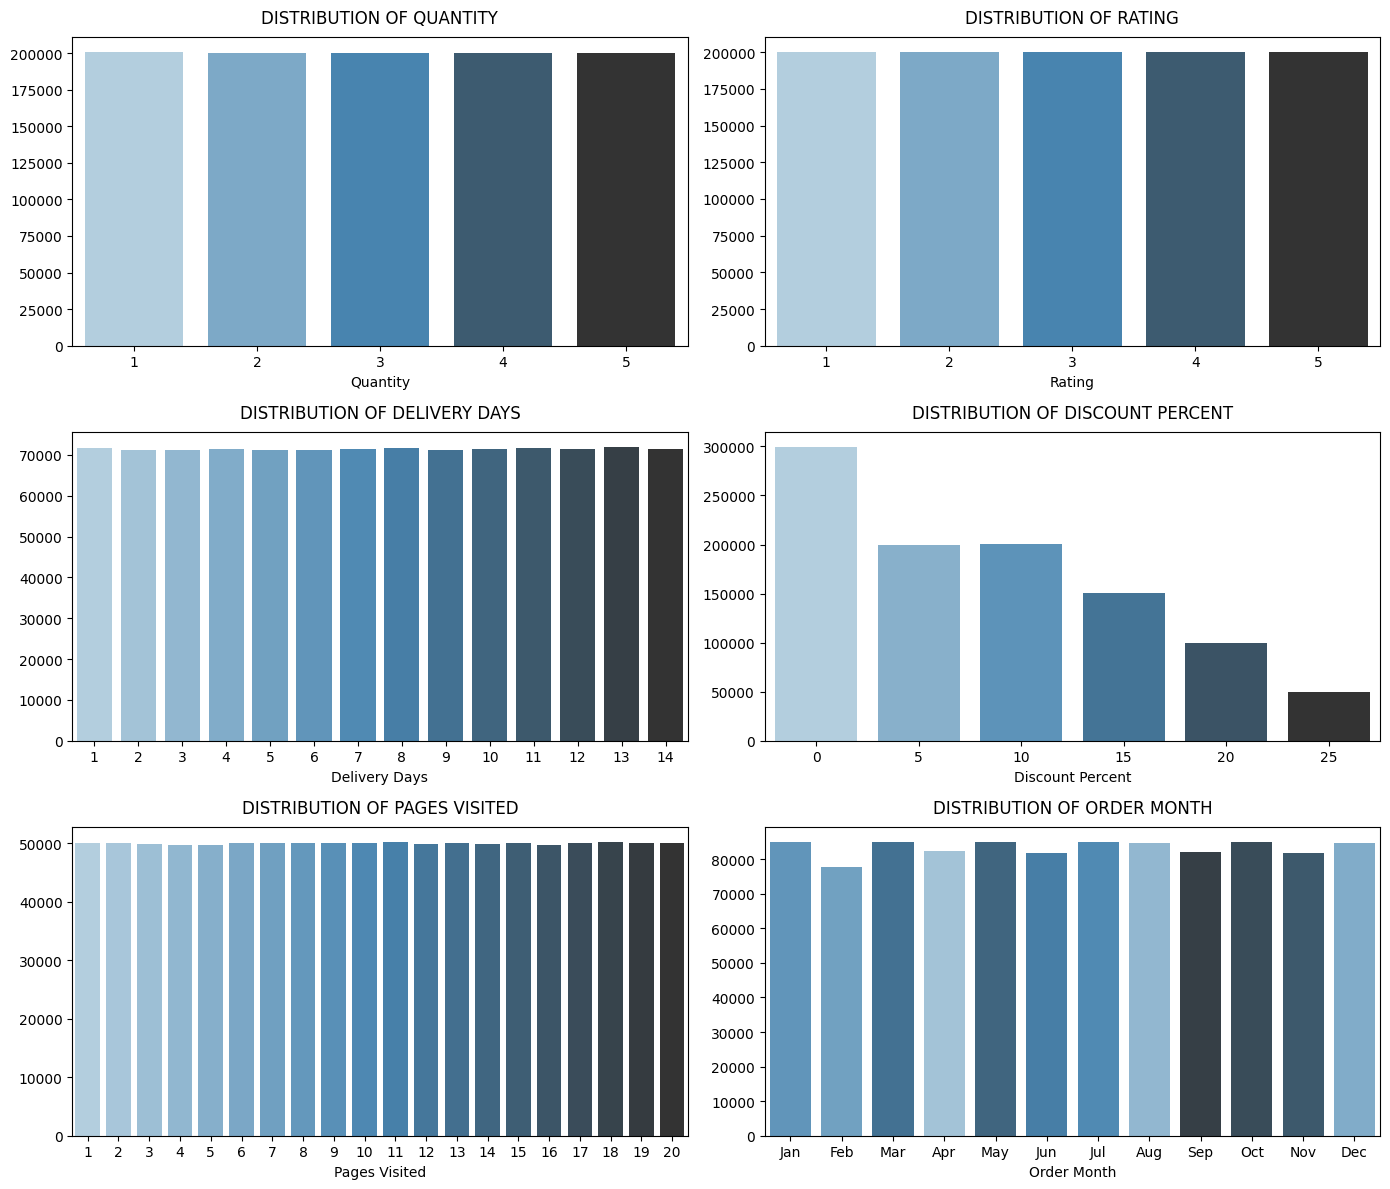

In [13]:
# Bar Graph of Discrete Variables
n_cols = 2
n_rows = math.ceil(len(discrete_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  

# Custom order for column that has natural sequence
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

eda_df['order_month'] = eda_df['order_month'].map(month_map)

# Then use this custom_order
custom_order = {
    'order_month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
}

for i, cons in enumerate(discrete_cols):
    ax = axes[i]
    count_plot = eda_df[cons].value_counts().sort_index()
    
    order = custom_order.get(cons, count_plot.index)
    
    sns.barplot(
        x=count_plot.index,
        y=count_plot.values,
        ax=ax,
        color='steelblue',
        palette='Blues_d',
        legend=False,
        hue=count_plot.index,
        order=order
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)

# Hide empty subplots (kung hindi exact multiple of 2)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

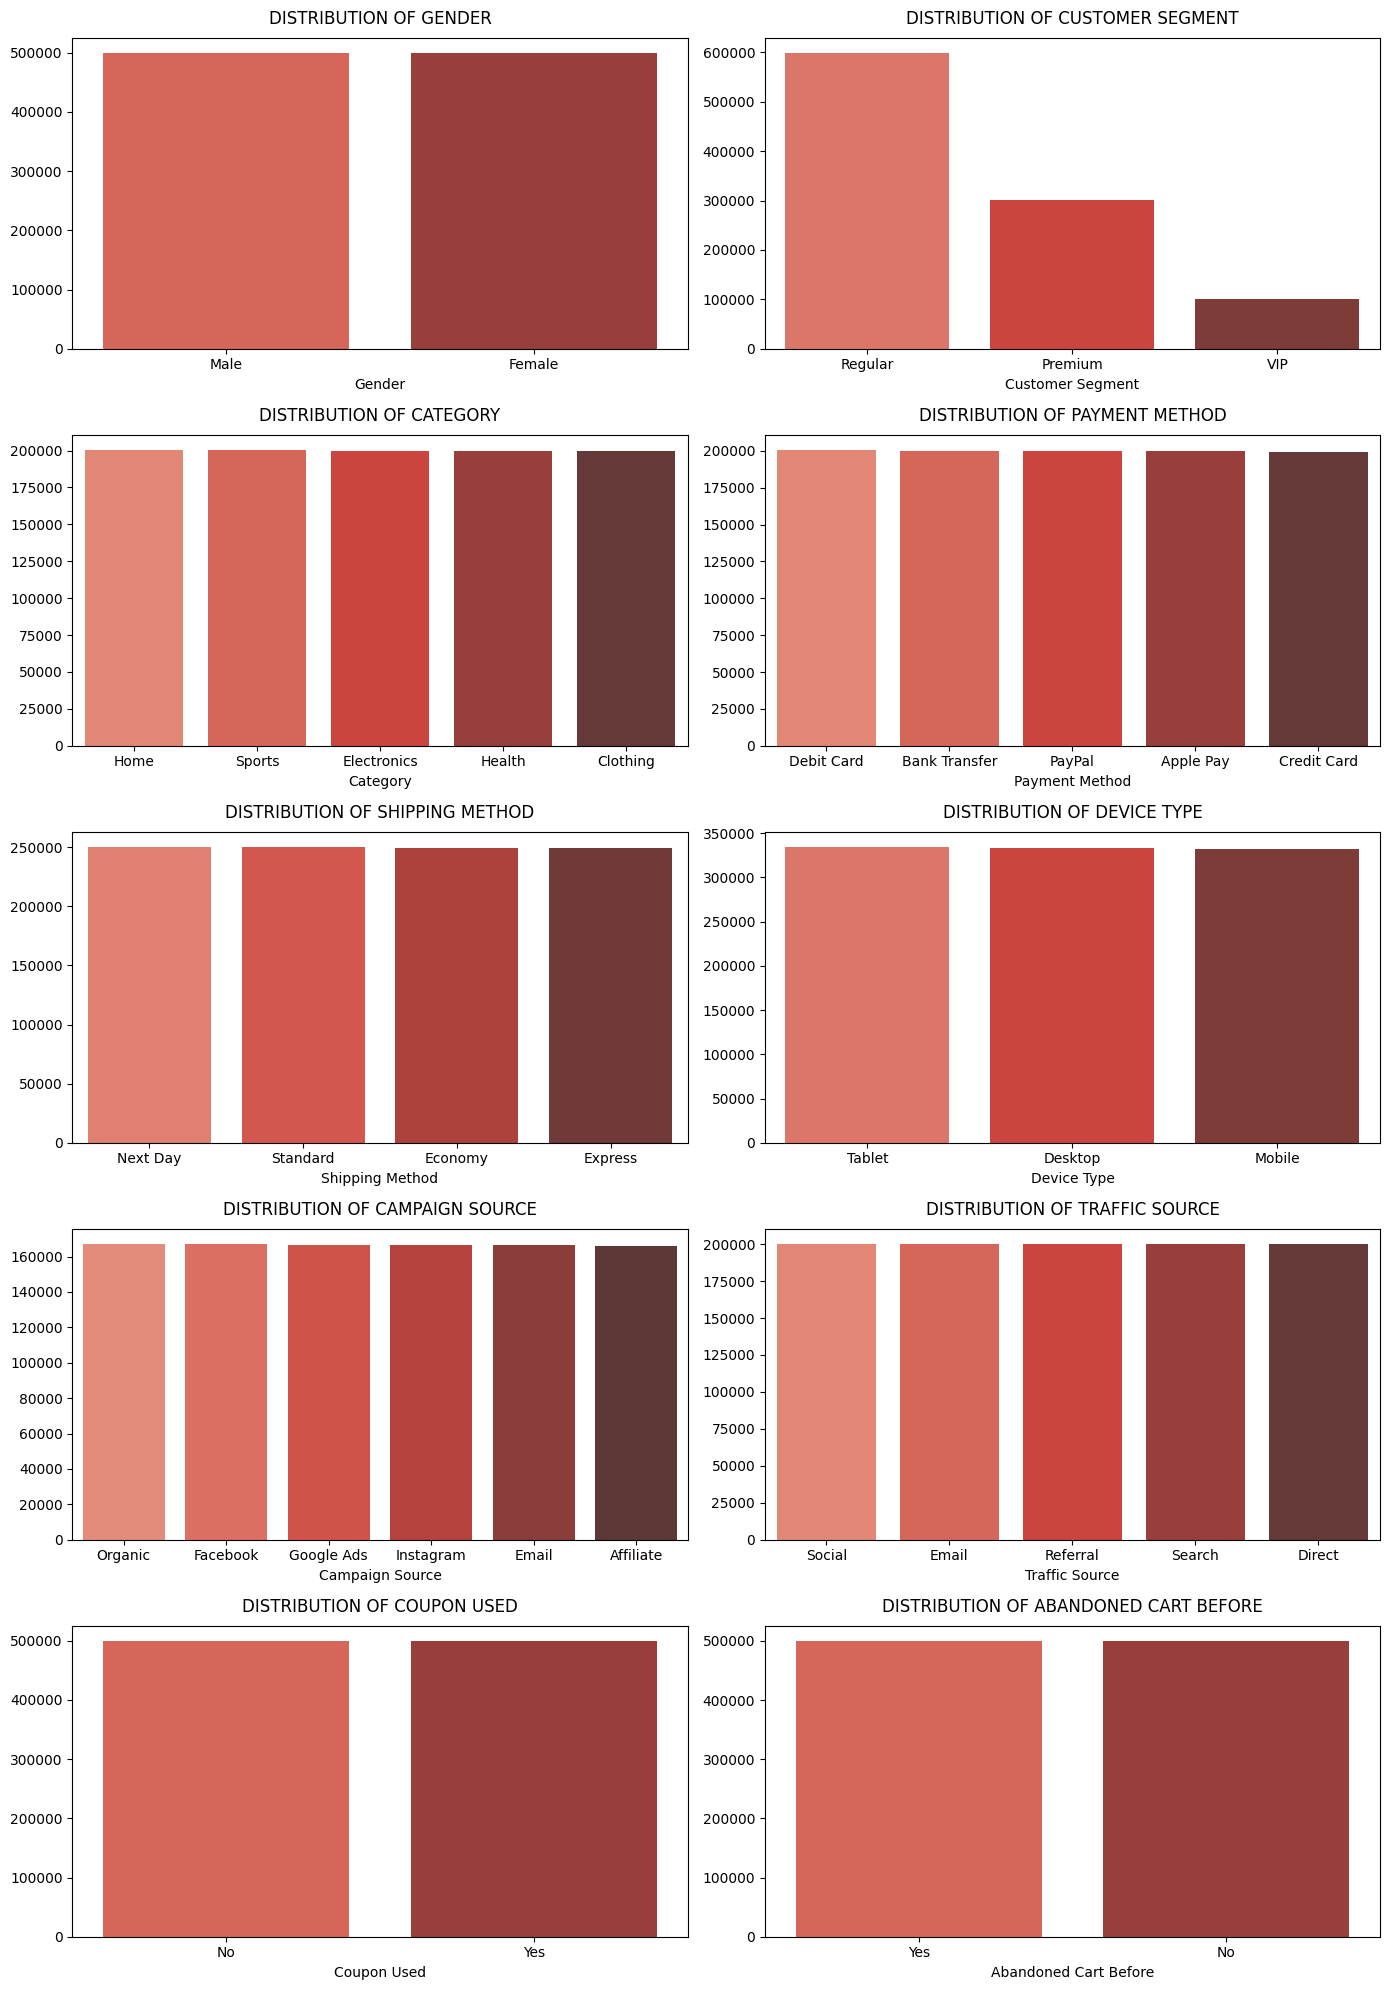

In [14]:
# Bar Graph of Categorical Variables
n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  


for i, cons in enumerate(categorical_cols):
    ax = axes[i]
    count_plot = eda_df[cons].value_counts().sort_values(ascending=False)
    
    sns.barplot(
        x=count_plot.index,
        y=count_plot.values,
        ax=ax,
        color='steelblue',
        palette='Reds_d',
        legend=False,
        hue=count_plot.index,
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)

# Hide empty subplots (kung hindi exact multiple of 2)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Heatmap, Correlation, and Pairplot